In [8]:
# Import the necessary packages
import time
import requests
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

import yfinance as yf

### Dowload and Clean ETF sector data

In [9]:
TICKERS = ["XLF", "XLC", "XLE", "XLB", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"]
START_DATE = "2000-01-01"

all_prices = []
for ticker in TICKERS:
    df = yf.download(ticker, start=START_DATE, progress=False, auto_adjust=False)["Adj Close"]
    all_prices.append(df)

In [10]:
prices = pd.concat(all_prices, axis=1)
prices.index = pd.to_datetime(prices.index, format="%Y-%m-%d")
prices = prices.dropna(how="any", axis=1) # truncated to 9 sectors due to missing data for some tickers

prices.to_csv("data/sector_etf_prices_cleaned.csv", index=True)

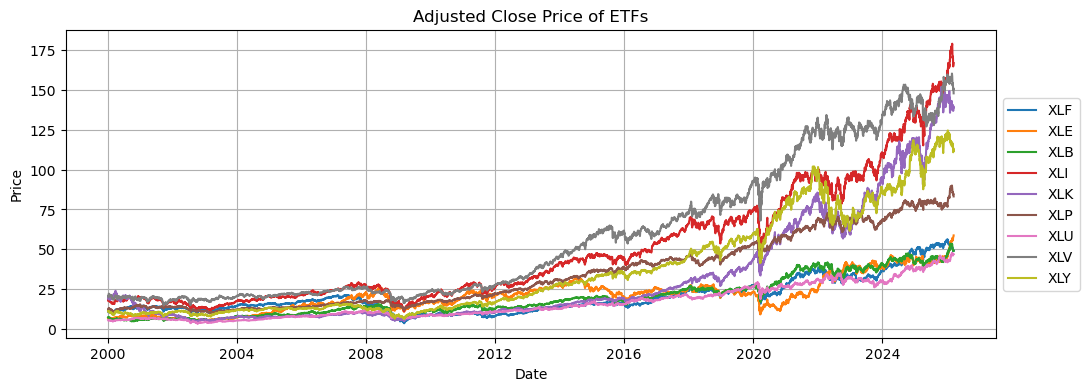

In [11]:
plt.figure(figsize=(12, 4))

for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)

plt.title("Adjusted Close Price of ETFs")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(loc="upper left", bbox_to_anchor=(1, 0.8))
plt.grid()
plt.show()

### Download S&P500 stock data

In [12]:
START_DATE  = "2000-01-01"
END_DATE    = date.today().isoformat()
BATCH_SIZE  = 50
OUTPUT_FILE = "data/SP500_AdjClose_Raw.csv"

SECTOR_MAP = {
    "Information Technology"  : "IT",
    "Health Care"             : "HC",
    "Financials"              : "FIN",
    "Consumer Discretionary"  : "CD",
    "Communication Services"  : "CS",
    "Industrials"             : "IND",
    "Consumer Staples"        : "CST",
    "Energy"                  : "ENE",
    "Utilities"               : "UTL",
    "Real Estate"             : "RE",
    "Materials"               : "MAT",
}

In [13]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
tables = pd.read_html(requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text)
df = tables[0]

ticker_map = {}
for _, row in df.iterrows():
    raw_ticker = row["Symbol"].replace(".", "-")
    sector = SECTOR_MAP.get(row["GICS Sector"], row["GICS Sector"].replace(" ", "_").upper())
    col_name = f"{sector}_{raw_ticker}"
    ticker_map[raw_ticker] = col_name

print(f"Found {len(ticker_map)} S&P 500 tickers across {df['GICS Sector'].nunique()} sectors")

C:\Users\Abbin\AppData\Local\Temp\ipykernel_23688\375137604.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text)


Found 503 S&P 500 tickers across 11 sectors


In [14]:
tickers = list(ticker_map.keys())
all_frames = []
batches = [tickers[i:i + BATCH_SIZE] for i in range(0, len(tickers), BATCH_SIZE)]
for idx, batch in enumerate(batches, 1):
    print(f"Batch {idx}/{len(batches)}: {batch[0]} … {batch[-1]}", end="  ")
    raw = yf.download(tickers = batch, start = START_DATE, end = END_DATE, auto_adjust = True, progress = False, threads = True)

    if isinstance(raw.columns, pd.MultiIndex):
        close = raw["Close"]
    else:
        close = raw[["Close"]].rename(columns={"Close": batch[0]})

    all_frames.append(close)
    print(f"→ {close.shape[1]} tickers, {close.shape[0]} rows")

df = pd.concat(all_frames, axis=1)
df.index.name = "Date"
df.sort_index(inplace=True)
df.rename(columns=ticker_map, inplace=True)
df.to_csv(OUTPUT_FILE, index=True)

Batch 1/11: MMM … ATO  → 50 tickers, 6590 rows
Batch 2/11: ADSK … CHTR  → 50 tickers, 6590 rows
Batch 3/11: CVX … FANG  → 50 tickers, 6590 rows
Batch 4/11: DLR … FE  → 50 tickers, 6590 rows
Batch 5/11: FISV … IR  → 50 tickers, 6590 rows
Batch 6/11: PODD … MRSH  → 50 tickers, 6590 rows
Batch 7/11: MLM … ODFL  → 50 tickers, 6590 rows
Batch 8/11: OMC … ROK  → 50 tickers, 6590 rows
Batch 9/11: ROL … TT  → 50 tickers, 6590 rows
Batch 10/11: TDG … YUM  → 50 tickers, 6590 rows
Batch 11/11: ZBRA … ZTS  → 3 tickers, 6590 rows


### Clean S&P500 stock data 

In [15]:
df_stocks = pd.read_csv("data/SP500_AdjClose_Raw.csv")
df_stocks["Date"] = pd.to_datetime(df_stocks["Date"], format="%Y-%m-%d")

df_stocks = df_stocks.dropna(how="any", axis=1)
remove_stocks = ['FIN_AIG', 'IND_PWR', 'HC_REGN', 'FIN_STT', 'ENE_WMB']
df_stocks = df_stocks.drop(columns=remove_stocks)

df_stocks.head()

,Date,HC_A,IT_AAPL,HC_ABT,FIN_ACGL,IT_ADBE,IT_ADI,CST_ADM,UTL_AEE,UTL_AEP,...,FIN_WFC,IND_WM,CST_WMT,FIN_WRB,CD_WSM,HC_WST,RE_WY,UTL_XEL,CD_YUM,IT_ZBRA
0,2000-01-03,43.036385,0.838496,8.093059,1.215037,16.274673,27.553602,5.968780,10.047227,10.137257,...,9.601672,9.646011,14.210656,0.776947,6.912109,5.395796,10.826267,6.529199,4.503592,25.027779
1,2000-01-04,39.748890,0.767802,7.861826,1.208433,14.909400,26.159672,5.906603,10.047227,10.258183,...,9.126183,9.611312,13.678919,0.753041,6.694250,5.451542,10.419556,6.679545,4.413067,24.666668
2,2000-01-05,37.283264,0.779038,7.847378,1.320692,15.204174,26.541574,5.813339,10.435897,10.641106,...,9.034155,9.646011,13.399762,0.741087,6.733863,5.429242,10.971523,6.937277,4.435701,25.138889
3,2000-01-06,35.863651,0.711621,8.121959,1.307485,15.328288,25.815987,5.844428,10.397025,10.701565,...,9.432947,9.576615,13.545989,0.784119,5.387090,5.373502,11.484751,6.872842,4.397980,23.777779
4,2000-01-07,38.852299,0.745330,8.208672,1.380124,16.072981,26.541574,5.937691,10.552494,10.842637,...,9.601672,9.194942,14.569583,0.772165,5.297964,5.429242,11.107089,6.872842,4.299914,23.513889


In [16]:
df_stocks.to_csv("data/SP500_AdjClose_Cleaned.csv", index=False)

In [17]:
df_stocks_logreturns = pd.DataFrame()
df_stocks_logreturns["Date"] = df_stocks["Date"]

for col in df_stocks.columns[1:]:
    df_stocks_logreturns[col] = np.log(df_stocks[col] / df_stocks[col].shift(1))

df_stocks_logreturns = df_stocks_logreturns.dropna(how="any", axis=0)

# returns_only = df_stocks_logreturns.drop(columns="Date")
# extreme_stocks = returns_only.columns[(returns_only.abs() > np.log(2.2)).any()]
# df_stocks_logreturns = df_stocks_logreturns.drop(columns=extreme_stocks)
# print(f"Removed {len(extreme_stocks)} stocks: {list(extreme_stocks)}")

C:\Users\Abbin\AppData\Local\Temp\ipykernel_23688\2630439361.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_stocks_logreturns[col] = np.log(df_stocks[col] / df_stocks[col].shift(1))
C:\Users\Abbin\AppData\Local\Temp\ipykernel_23688\2630439361.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_stocks_logreturns[col] = np.log(df_stocks[col] / df_stocks[col].shift(1))
C:\Users\Abbin\AppData\Local\Temp\ipykernel_23688\2630439361.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

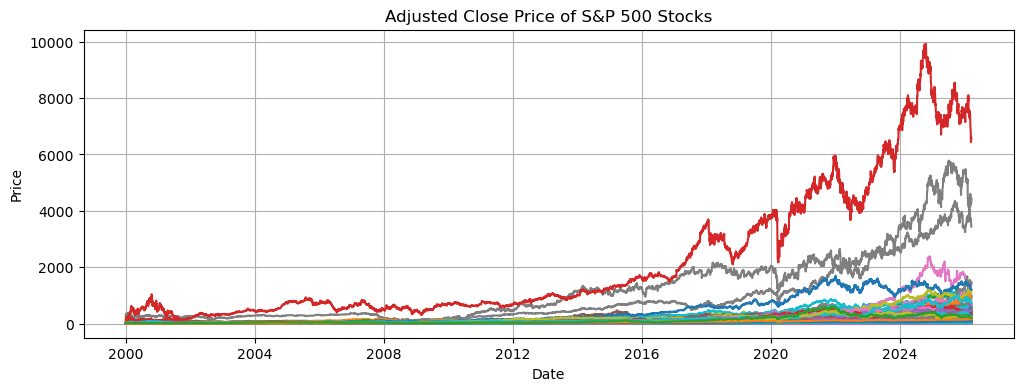

In [18]:
plt.figure(figsize=(12, 4))

for col in df_stocks.columns[1:]:
    plt.plot(df_stocks["Date"], df_stocks[col], label=col)

plt.title("Adjusted Close Price of S&P 500 Stocks")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

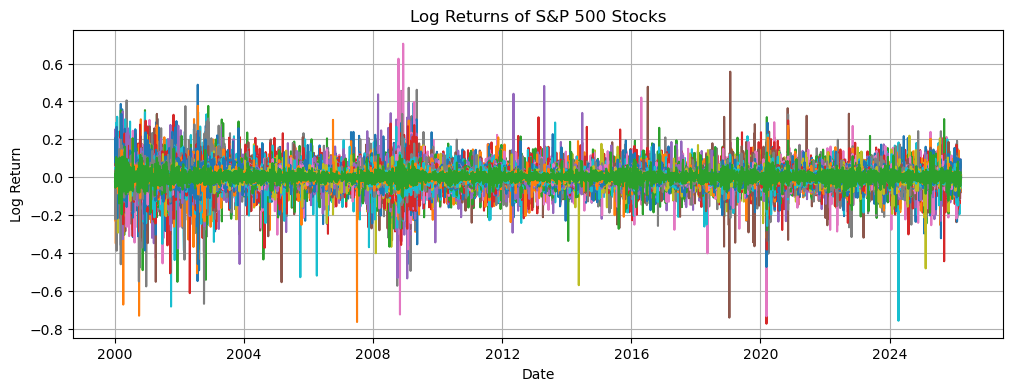

In [19]:
plt.figure(figsize=(12, 4))

for col in df_stocks_logreturns.columns[1:]:
    plt.plot(df_stocks_logreturns["Date"], df_stocks_logreturns[col], label=col)

plt.title("Log Returns of S&P 500 Stocks")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid()
plt.show()

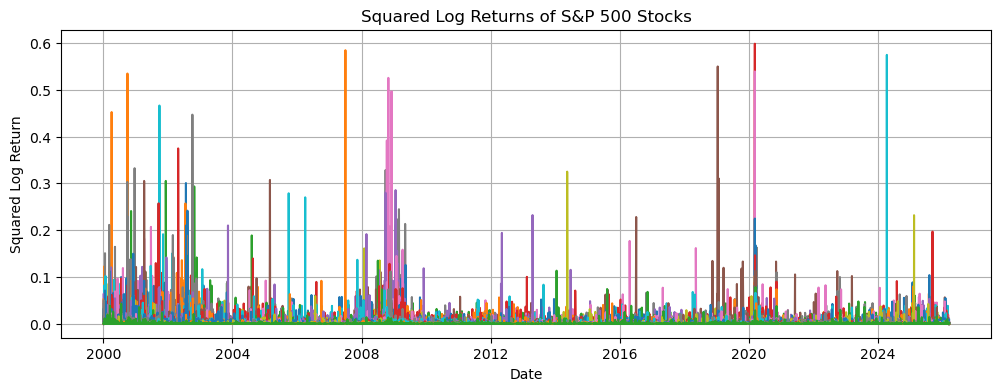

In [20]:
plt.figure(figsize=(12, 4))

for col in df_stocks_logreturns.columns[1:]:
    plt.plot(df_stocks_logreturns["Date"], df_stocks_logreturns[col]**2, label=col)

plt.title("Squared Log Returns of S&P 500 Stocks")
plt.xlabel("Date")
plt.ylabel("Squared Log Return")
plt.grid()
plt.show()